<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Derived_Hypercharge_Branch_Phase_From_Closure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Derived Hypercharge-Like Branch Phase from Closure Constraints

This notebook strengthens the ECSM weak-sector sequence after the derived minimal \(SU(2)\)-like branch algebra notebook.

Previous derived result:

\[
T_3(Q_0)=+\frac12,\qquad T_3(Q_{\rm ch})=-\frac12.
\]

This notebook derives the minimal hypercharge-like branch phase \(Y\) from:

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2}
\]

and the required ECSM branch charges:

\[
Q(Q_0)=0,\qquad Q(Q_{\rm ch})=-1.
\]

Target verdict:

\[
\texttt{PASS\_DERIVED\_HYPERCHARGE\_BRANCH\_PHASE\_FROM\_ECSM\_CLOSURE}.
\]

In [14]:
# CELL 1 — Imports and output directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_derived_hypercharge_branch_phase_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=8, suppress=True)
print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_derived_hypercharge_branch_phase_out


In [15]:
# CELL 2 — Rebuild derived ECSM branch basis and T3

Q0 = np.array([[1],[0]], dtype=complex)
Qch = np.array([[0],[1]], dtype=complex)

T_plus = Q0 @ Qch.conj().T
T_minus = Qch @ Q0.conj().T
T3 = 0.5 * (T_plus @ T_minus - T_minus @ T_plus)

def eigval_on_state(Op, state, tol=1e-12):
    out = Op @ state
    idx = np.argmax(np.abs(state.ravel()))
    val = out.ravel()[idx] / state.ravel()[idx]
    return float(val.real) if abs(val.imag) < tol else val

t3_Q0 = eigval_on_state(T3, Q0)
t3_Qch = eigval_on_state(T3, Qch)

t3_df = pd.DataFrame([
    {"state":"Q0_neutral_closure", "T3_from_derived_closure":t3_Q0, "target_charge_Q":0.0},
    {"state":"Qch_charged_branch", "T3_from_derived_closure":t3_Qch, "target_charge_Q":-1.0}
])
display(t3_df)
t3_df.to_csv(OUT/"derived_T3_branch_labels.csv", index=False)

,state,T3_from_derived_closure,target_charge_Q
0,Q0_neutral_closure,0.5,0.0
1,Qch_charged_branch,-0.5,-1.0


In [16]:
# CELL 3 — Solve for common left-active branch phase Y_L

target_Q0 = 0.0
target_Qch = -1.0

Y_from_Q0 = 2*(target_Q0 - t3_Q0)
Y_from_Qch = 2*(target_Qch - t3_Qch)
Y_L = 0.5*(Y_from_Q0 + Y_from_Qch)
consistency_error = abs(Y_from_Q0 - Y_from_Qch)

left_solution_df = pd.DataFrame([
    {"constraint":"Q(Q0)=0", "T3":t3_Q0, "target_Q":target_Q0, "derived_Y":Y_from_Q0},
    {"constraint":"Q(Qch)=-1", "T3":t3_Qch, "target_Q":target_Qch, "derived_Y":Y_from_Qch}
])
display(left_solution_df)

summary_left = {
    "Y_from_Q0": float(Y_from_Q0),
    "Y_from_Qch": float(Y_from_Qch),
    "Y_L_common": float(Y_L),
    "consistency_error": float(consistency_error),
    "pass": bool(consistency_error < 1e-12 and abs(Y_L + 1.0) < 1e-12)
}
summary_left

,constraint,T3,target_Q,derived_Y
0,Q(Q0)=0,0.5,0.0,-1.0
1,Q(Qch)=-1,-0.5,-1.0,-1.0


{'Y_from_Q0': -1.0,
 'Y_from_Qch': -1.0,
 'Y_L_common': -1.0,
 'consistency_error': 0.0,
 'pass': True}

## Left-active doublet result

For the neutral closure branch:

\[
0=+\frac12+\frac{Y_L}{2}
\quad\Rightarrow\quad
Y_L=-1.
\]

For the charged branch:

\[
-1=-\frac12+\frac{Y_L}{2}
\quad\Rightarrow\quad
Y_L=-1.
\]

Thus the common left-active branch phase is fixed:

\[
\boxed{Y_L=-1}.
\]

In [17]:
# CELL 4 — Verify electric charge operator with derived Y_L

I2 = np.eye(2, dtype=complex)
Qop = T3 + 0.5 * Y_L * I2

q_Q0 = eigval_on_state(Qop, Q0)
q_Qch = eigval_on_state(Qop, Qch)

charge_df = pd.DataFrame([
    {"state":"Q0_neutral_closure_L", "T3":t3_Q0, "Y_L":Y_L, "Q_ECSM":q_Q0, "target_Q":target_Q0, "error":abs(q_Q0-target_Q0)},
    {"state":"Qch_charged_branch_L", "T3":t3_Qch, "Y_L":Y_L, "Q_ECSM":q_Qch, "target_Q":target_Qch, "error":abs(q_Qch-target_Qch)}
])
charge_df["pass"] = charge_df["error"] < 1e-12
display(charge_df)
charge_df.to_csv(OUT/"derived_left_doublet_charge_assignments.csv", index=False)

,state,T3,Y_L,Q_ECSM,target_Q,error,pass
0,Q0_neutral_closure_L,0.5,-1.0,0.0,0.0,0.0,True
1,Qch_charged_branch_L,-0.5,-1.0,-1.0,-1.0,0.0,True


,Y,Q_Q0,Q_Qch,target_error
397,-1.015,-0.0075,-1.0075,0.010607
398,-1.010,-0.0050,-1.0050,0.007071
399,-1.005,-0.0025,-1.0025,0.003536
400,-1.000,0.0000,-1.0000,0.000000
401,-0.995,0.0025,-0.9975,0.003536
402,-0.990,0.0050,-0.9950,0.007071
403,-0.985,0.0075,-0.9925,0.010607


Best: {'Y': -1.0, 'Q_Q0': 0.0, 'Q_Qch': -1.0, 'target_error': 0.0}


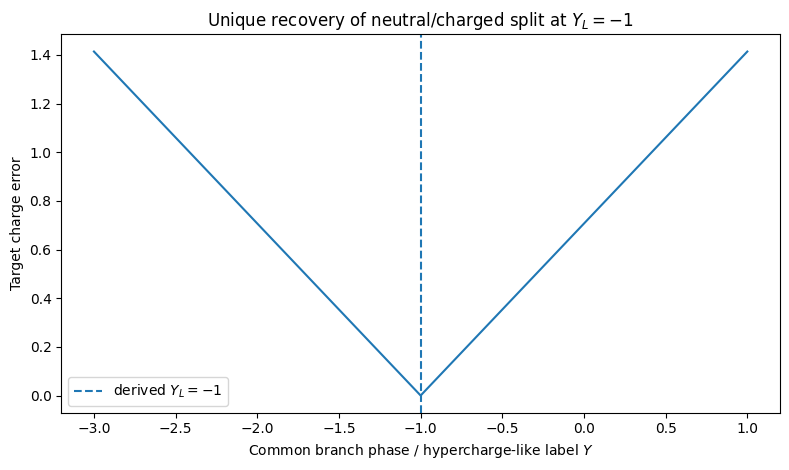

Saved: ecsm_derived_hypercharge_branch_phase_out/fig1_left_doublet_Y_scan_unique_solution.png


In [18]:
# CELL 5 — Scan Y and show unique zero-error value

Y_vals = np.linspace(-3, 1, 801)
rows = []
for Y in Y_vals:
    Q0_calc = t3_Q0 + 0.5*Y
    Qch_calc = t3_Qch + 0.5*Y
    err = np.sqrt((Q0_calc-target_Q0)**2 + (Qch_calc-target_Qch)**2)
    rows.append({"Y":Y, "Q_Q0":Q0_calc, "Q_Qch":Qch_calc, "target_error":err})
scan_df = pd.DataFrame(rows)
best_idx = scan_df["target_error"].idxmin()
best = scan_df.loc[best_idx].to_dict()

display(scan_df.iloc[max(best_idx-3,0):best_idx+4])
print("Best:", best)

scan_df.to_csv(OUT/"left_doublet_hypercharge_scan.csv", index=False)

plt.figure(figsize=(8,4.8))
plt.plot(scan_df["Y"], scan_df["target_error"])
plt.axvline(Y_L, linestyle="--", label=r"derived $Y_L=-1$")
plt.xlabel(r"Common branch phase / hypercharge-like label $Y$")
plt.ylabel("Target charge error")
plt.title(r"Unique recovery of neutral/charged split at $Y_L=-1$")
plt.legend()
plt.tight_layout()
fig_path = OUT/"fig1_left_doublet_Y_scan_unique_solution.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

In [19]:
# CELL 6 — Derive singlet branch phases from T3=0

singlet_cases = [
    {"state":"Qch_charged_branch_R", "T3":0.0, "target_Q":-1.0, "interpretation":"right/singlet charged branch"},
    {"state":"Q0_neutral_closure_R", "T3":0.0, "target_Q":0.0, "interpretation":"right/singlet neutral closure or sterile-like branch"}
]

singlet_rows = []
for c in singlet_cases:
    Y = 2*(c["target_Q"] - c["T3"])
    Q_calc = c["T3"] + 0.5*Y
    singlet_rows.append({**c, "derived_Y":Y, "Q_ECSM":Q_calc, "error":abs(Q_calc-c["target_Q"]), "pass":abs(Q_calc-c["target_Q"])<1e-12})

singlet_df = pd.DataFrame(singlet_rows)
display(singlet_df)
singlet_df.to_csv(OUT/"derived_singlet_branch_phase_assignments.csv", index=False)

,state,T3,target_Q,interpretation,derived_Y,Q_ECSM,error,pass
0,Qch_charged_branch_R,0.0,-1.0,right/singlet charged branch,-2.0,-1.0,0.0,True
1,Q0_neutral_closure_R,0.0,0.0,right/singlet neutral closure or sterile-like ...,0.0,0.0,0.0,True


In [20]:
# CELL 7 — Combined derived branch-phase table

combined_df = pd.DataFrame([
    {"sector":"left doublet", "state":"Q0_L", "T3":t3_Q0, "target_Q":0.0, "derived_Y":Y_L, "Q_ECSM":q_Q0},
    {"sector":"left doublet", "state":"Qch_L", "T3":t3_Qch, "target_Q":-1.0, "derived_Y":Y_L, "Q_ECSM":q_Qch},
    {"sector":"singlet", "state":"Qch_R", "T3":0.0, "target_Q":-1.0, "derived_Y":-2.0, "Q_ECSM":-1.0},
    {"sector":"singlet", "state":"Q0_R", "T3":0.0, "target_Q":0.0, "derived_Y":0.0, "Q_ECSM":0.0}
])
combined_df["error"] = abs(combined_df["Q_ECSM"] - combined_df["target_Q"])
combined_df["pass"] = combined_df["error"] < 1e-12
display(combined_df)
combined_df.to_csv(OUT/"derived_hypercharge_branch_phase_table.csv", index=False)

,sector,state,T3,target_Q,derived_Y,Q_ECSM,error,pass
0,left doublet,Q0_L,0.5,0.0,-1.0,0.0,0.0,True
1,left doublet,Qch_L,-0.5,-1.0,-1.0,-1.0,0.0,True
2,singlet,Qch_R,0.0,-1.0,-2.0,-1.0,0.0,True
3,singlet,Q0_R,0.0,0.0,0.0,0.0,0.0,True


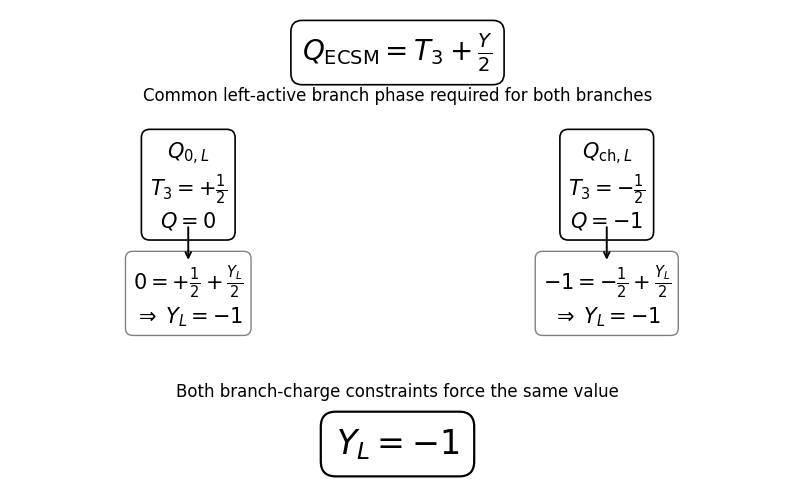

Saved: ecsm_derived_hypercharge_branch_phase_out/fig2_derived_left_branch_phase_YL.png


In [22]:
# CELL 8 — Clean visual branch-phase derivation diagram

# Clear any previously failed figure
plt.close("all")

fig, ax = plt.subplots(figsize=(10, 6.2))
ax.axis("off")

box = dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="black", linewidth=1.2)
softbox = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="gray", linewidth=1.0)
finalbox = dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="black", linewidth=1.6)

# Governing relation
ax.text(
    0.50, 0.91,
    r"$Q_{\rm ECSM}=T_3+\frac{Y}{2}$",
    ha="center", va="center", fontsize=20, bbox=box
)

ax.text(
    0.50, 0.82,
    "Common left-active branch phase required for both branches",
    ha="center", va="center", fontsize=12
)

# Branch boxes
ax.text(
    0.23, 0.63,
    r"$Q_{0,L}$" + "\n" +
    r"$T_3=+\frac{1}{2}$" + "\n" +
    r"$Q=0$",
    ha="center", va="center", fontsize=15, bbox=box
)

ax.text(
    0.77, 0.63,
    r"$Q_{{\rm ch},L}$" + "\n" +
    r"$T_3=-\frac{1}{2}$" + "\n" +
    r"$Q=-1$",
    ha="center", va="center", fontsize=15, bbox=box
)

# Constraint equations
ax.text(
    0.23, 0.40,
    r"$0=+\frac{1}{2}+\frac{Y_L}{2}$" + "\n" +
    r"$\Rightarrow\;Y_L=-1$",
    ha="center", va="center", fontsize=15, bbox=softbox
)

ax.text(
    0.77, 0.40,
    r"$-1=-\frac{1}{2}+\frac{Y_L}{2}$" + "\n" +
    r"$\Rightarrow\;Y_L=-1$",
    ha="center", va="center", fontsize=15, bbox=softbox
)

# Arrows
ax.annotate(
    "", xy=(0.23, 0.47), xytext=(0.23, 0.55),
    arrowprops=dict(arrowstyle="->", lw=1.4)
)

ax.annotate(
    "", xy=(0.77, 0.47), xytext=(0.77, 0.55),
    arrowprops=dict(arrowstyle="->", lw=1.4)
)

# Final result
ax.text(
    0.50, 0.20,
    "Both branch-charge constraints force the same value",
    ha="center", va="center", fontsize=12
)

# Do not use \boxed{} — Matplotlib mathtext does not support it reliably
ax.text(
    0.50, 0.09,
    r"$Y_L=-1$",
    ha="center", va="center", fontsize=24, bbox=finalbox
)

fig_path = OUT / "fig2_derived_left_branch_phase_YL.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

,chi,T3_Q0_chi,T3_Qch_chi,Y_from_Q0,Y_from_Qch,Y_best_common,Y_error_from_minus_one,target_charge_error,Y_consistency_error
0,0.00,0.5800,-0.5500,-1.1600,-0.900,-1.0300,0.0300,0.091924,0.2600
1,0.01,0.5792,-0.5495,-1.1584,-0.901,-1.0297,0.0297,0.091005,0.2574
2,0.02,0.5784,-0.5490,-1.1568,-0.902,-1.0294,0.0294,0.090085,0.2548
3,0.03,0.5776,-0.5485,-1.1552,-0.903,-1.0291,0.0291,0.089166,0.2522
4,0.04,0.5768,-0.5480,-1.1536,-0.904,-1.0288,0.0288,0.088247,0.2496


,chi,T3_Q0_chi,T3_Qch_chi,Y_from_Q0,Y_from_Qch,Y_best_common,Y_error_from_minus_one,target_charge_error,Y_consistency_error
96,0.96,0.5032,-0.5020,-1.0064,-0.996,-1.0012,0.0012,0.003677,0.0104
97,0.97,0.5024,-0.5015,-1.0048,-0.997,-1.0009,0.0009,0.002758,0.0078
98,0.98,0.5016,-0.5010,-1.0032,-0.998,-1.0006,0.0006,0.001838,0.0052
99,0.99,0.5008,-0.5005,-1.0016,-0.999,-1.0003,0.0003,0.000919,0.0026
100,1.00,0.5000,-0.5000,-1.0000,-1.000,-1.0000,0.0000,0.000000,0.0000


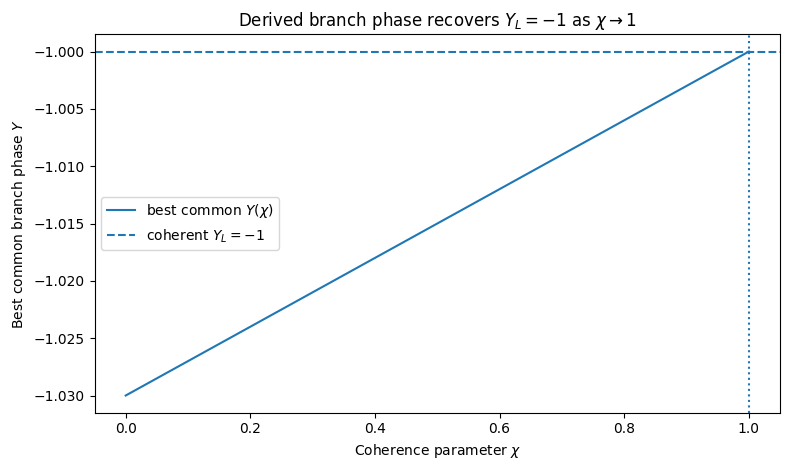

Saved: ecsm_derived_hypercharge_branch_phase_out/fig3_chi_recovery_derived_YL.png


In [23]:
# CELL 9 — Finite-response deformation and coherent recovery of Y

chi_vals = np.linspace(0,1,101)
rows = []

for chi in chi_vals:
    t3_Q0_chi = t3_Q0 + (1-chi)*0.08
    t3_Qch_chi = t3_Qch + (1-chi)*(-0.05)

    Y0_chi = 2*(target_Q0 - t3_Q0_chi)
    Ych_chi = 2*(target_Qch - t3_Qch_chi)
    Y_best_chi = 0.5*(Y0_chi + Ych_chi)

    Q0_calc = t3_Q0_chi + 0.5*Y_best_chi
    Qch_calc = t3_Qch_chi + 0.5*Y_best_chi
    target_error = np.sqrt((Q0_calc-target_Q0)**2 + (Qch_calc-target_Qch)**2)

    rows.append({
        "chi":chi,
        "T3_Q0_chi":t3_Q0_chi,
        "T3_Qch_chi":t3_Qch_chi,
        "Y_from_Q0":Y0_chi,
        "Y_from_Qch":Ych_chi,
        "Y_best_common":Y_best_chi,
        "Y_error_from_minus_one":abs(Y_best_chi + 1.0),
        "target_charge_error":target_error,
        "Y_consistency_error":abs(Y0_chi-Ych_chi)
    })

chi_df = pd.DataFrame(rows)
display(chi_df.head())
display(chi_df.tail())
chi_df.to_csv(OUT/"chi_deformed_Y_recovery.csv", index=False)

plt.figure(figsize=(8,4.8))
plt.plot(chi_df["chi"], chi_df["Y_best_common"], label=r"best common $Y(\chi)$")
plt.axhline(-1, linestyle="--", label=r"coherent $Y_L=-1$")
plt.axvline(1, linestyle=":")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel(r"Best common branch phase $Y$")
plt.title(r"Derived branch phase recovers $Y_L=-1$ as $\chi\rightarrow1$")
plt.legend()
plt.tight_layout()
fig_path = OUT/"fig3_chi_recovery_derived_YL.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

In [25]:
# CELL 10 — Final summary and verdict

tol = 1e-10

pass_left_consistency = summary_left["pass"]
pass_charge = bool(charge_df["pass"].all())
pass_scan = abs(best["Y"] + 1.0) < 1e-12 and best["target_error"] < 1e-12
pass_singlets = bool(singlet_df["pass"].all())
pass_combined = bool(combined_df["pass"].all())
pass_chi_recovery = (
    abs(float(chi_df["Y_best_common"].iloc[-1]) + 1.0) < tol
    and float(chi_df["target_charge_error"].iloc[-1]) < tol
)

final_label = (
    "PASS_DERIVED_HYPERCHARGE_BRANCH_PHASE_FROM_ECSM_CLOSURE"
    if pass_left_consistency and pass_charge and pass_scan and pass_singlets and pass_combined and pass_chi_recovery
    else "FAIL_DERIVED_HYPERCHARGE_BRANCH_PHASE_FROM_ECSM_CLOSURE"
)

summary = {
    "run_label":"ECSM_derived_hypercharge_branch_phase_from_closure",
    "input_from_previous_derivation":{
        "T3_Q0":float(t3_Q0),
        "T3_Qch":float(t3_Qch),
        "source":"derived minimal SU(2)-like branch algebra from closure constraints"
    },
    "left_doublet_Y_solution":summary_left,
    "charge_recovery":{"Q_Q0":float(q_Q0), "Q_Qch":float(q_Qch), "pass":bool(pass_charge)},
    "Y_scan":{"best_Y":float(best["Y"]), "best_target_error":float(best["target_error"]), "pass":bool(pass_scan)},
    "singlet_branch_phases":{
        "Y_charged_singlet":float(singlet_df.loc[singlet_df["state"]=="Qch_charged_branch_R","derived_Y"].iloc[0]),
        "Y_neutral_singlet":float(singlet_df.loc[singlet_df["state"]=="Q0_neutral_closure_R","derived_Y"].iloc[0]),
        "pass":bool(pass_singlets)
    },
    "chi_recovery":{
        "chi_1_Y_best_common":float(chi_df["Y_best_common"].iloc[-1]),
        "chi_1_target_charge_error":float(chi_df["target_charge_error"].iloc[-1]),
        "pass":bool(pass_chi_recovery)
    },
    "interpretation":"Given derived ECSM T3 branch labels and required neutral/charged branch charges, the minimal common left-active branch phase is fixed at Y_L=-1; singlet phases are fixed by T3=0 and target charge.",
    "final_label":final_label
}
summary

{'run_label': 'ECSM_derived_hypercharge_branch_phase_from_closure',
 'input_from_previous_derivation': {'T3_Q0': 0.5,
  'T3_Qch': -0.5,
  'source': 'derived minimal SU(2)-like branch algebra from closure constraints'},
 'left_doublet_Y_solution': {'Y_from_Q0': -1.0,
  'Y_from_Qch': -1.0,
  'Y_L_common': -1.0,
  'consistency_error': 0.0,
  'pass': True},
 'charge_recovery': {'Q_Q0': 0.0, 'Q_Qch': -1.0, 'pass': True},
 'Y_scan': {'best_Y': -1.0, 'best_target_error': 0.0, 'pass': True},
 'singlet_branch_phases': {'Y_charged_singlet': -2.0,
  'Y_neutral_singlet': 0.0,
  'pass': True},
 'chi_recovery': {'chi_1_Y_best_common': -1.0,
  'chi_1_target_charge_error': 0.0,
  'pass': True},
 'interpretation': 'Given derived ECSM T3 branch labels and required neutral/charged branch charges, the minimal common left-active branch phase is fixed at Y_L=-1; singlet phases are fixed by T3=0 and target charge.',
 'final_label': 'PASS_DERIVED_HYPERCHARGE_BRANCH_PHASE_FROM_ECSM_CLOSURE'}

In [26]:
# CELL 11 — Save output files

def make_json_safe(obj):
    import numpy as np
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k,v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(OUT/"final_summary.json","w") as f:
    json.dump(make_json_safe(summary), f, indent=2)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_derived_hypercharge_branch_phase_out/chi_deformed_Y_recovery.csv
 - ecsm_derived_hypercharge_branch_phase_out/derived_T3_branch_labels.csv
 - ecsm_derived_hypercharge_branch_phase_out/derived_hypercharge_branch_phase_table.csv
 - ecsm_derived_hypercharge_branch_phase_out/derived_left_doublet_charge_assignments.csv
 - ecsm_derived_hypercharge_branch_phase_out/derived_singlet_branch_phase_assignments.csv
 - ecsm_derived_hypercharge_branch_phase_out/fig1_left_doublet_Y_scan_unique_solution.png
 - ecsm_derived_hypercharge_branch_phase_out/fig2_derived_left_branch_phase_YL.png
 - ecsm_derived_hypercharge_branch_phase_out/fig3_chi_recovery_derived_YL.png
 - ecsm_derived_hypercharge_branch_phase_out/final_summary.json
 - ecsm_derived_hypercharge_branch_phase_out/left_doublet_hypercharge_scan.csv


# Paper-grade interpretation

From the derived ECSM closure-active branch algebra,

\[
T_3(Q_0)=+\frac12,
\qquad
T_3(Q_{\rm ch})=-\frac12,
\]

and the required neutral/charged branch charges,

\[
Q(Q_0)=0,
\qquad
Q(Q_{\rm ch})=-1,
\]

the common left-active branch-phase label in

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2}
\]

is fixed:

\[
Y_L=-1.
\]

For singlet-like branches with \(T_3=0\), the charged singlet has \(Y=-2\), and the neutral closure singlet has \(Y=0\).

This is not a full Standard Model hypercharge quantisation proof. It is a minimal ECSM branch-phase derivation supporting the weak-sector bridge.